# ADEPT Architectural Analysis: Pipes and Filters Pattern
This notebook provides a walkthrough of the ADEPT framework's analysis pipeline applied to the **Pipes and Filters** pattern. We investigate how different pipeline configurations (e.g., separating or combining filters) impact performance metrics like **Response Time** and **Throughput** under varying load conditions.

In [124]:
# Set project root in path so we can import 'adept' package
import sys
sys.path.append("../../")

# %matplotlib inline
import itertools
import pandas as pd
import matplotlib.pyplot as plt

from adept import PatternAnalysis

## 1. Preprocessing Logic
Raw simulation data often contains tool-specific column names and numeric identifiers. In this step, we:
- **Rename outputs**: Map `R0` to `response_time` and `X0` to `throughput`.
- **Handle Configurations**: Normalize data from different simulation files (`separated`, `joint1`, `joint2`) which have different sets of active parameters.
- **Fill Missing Values**: Ensure parameter sets are consistent across all configurations by filling missing fields (e.g., inactive filter capacities) with default values.
- **Standardize Schema**: Create a unified `policy` column to distinguish between architectural variants.

In [125]:
# Specific parameters for Pipes and Filters

COMMON_PARAMETERS = ['N_A', 'N_B', 'r_Z_A', 'r_Z_B']
ADDITIONAL_PARAMETERS_SEPARATED = ['c_A_T1','c_A_T2','c_A_T3','c_B_T1','c_B_T2','c_B_T4','r_A_T1','r_A_T2','r_A_T3','r_B_T1','r_B_T2','r_B_T4']
ADDITIONAL_PARAMETERS_JOINT = ['c_T1','c_T2','c_T3','c_T4','r_A_T1','r_B_T1','r_A_T2','r_B_T2','r_A_T3','r_B_T4']

INPUT_PARAMETERS_SEPARATED = COMMON_PARAMETERS + ADDITIONAL_PARAMETERS_SEPARATED
INPUT_PARAMETERS_JOINT = COMMON_PARAMETERS + ADDITIONAL_PARAMETERS_JOINT

OUTPUTS = ['response_time', 'throughput'] 
# N = 50

def preprocess_pipesandfilters(df: pd.DataFrame, config_name: str=None) -> pd.DataFrame:

    print(f"Preprocessing {config_name}: {df.shape}")
    # print(df.columns)
    
    df.rename(columns={'R0': 'response_time', 'X0': 'throughput'}, inplace=True)

    # df = df[df['N_A']+df['N_B']==self.N]
    df.sort_values(by='N_A', inplace=True)
    # df['N_A/N'] = df['N_A'] / self.N

    if (config_name == 'separated'):
        experiments_df = df[INPUT_PARAMETERS_SEPARATED].copy()
        # experiments_df['N_A/N'] = df['N_A/N']
    if (config_name == 'joint1') or (config_name == 'joint2'):
        experiments_df = df[INPUT_PARAMETERS_JOINT].copy()
        # experiments_df['N_A/N'] = df['N_A/N']
    
    experiments_df.fillna(0.0, inplace=True) # TODO: Review this need
    
    experiments_df['policy'] = config_name
    experiments_df['policy'] = experiments_df['policy'].astype('category')
    experiments_df.index.name = 'scenario'
    experiments_df.reset_index(inplace=True)
    experiments_df['model'] = 'pipes_and_filters'
    
    experiments_df[OUTPUTS] = df[OUTPUTS].copy()
    # experiments_df.reset_index(inplace=True, drop=True)

    return experiments_df


In [126]:
# test_df = pd.read_csv("./separated/Core1_N50.csv")
# preprocess_pipesandfilters(test_df, config_name="separated")


In [127]:
# test_df = pd.read_csv("./joint/Core1_N50.csv")
# preprocess_pipesandfilters(test_df, config_name="joint2")


In [128]:
# test_df = pd.read_csv("./joint/Core2_N50.csv")
# preprocess_pipesandfilters(test_df, config_name="joint1")


## 2. Initialize and Load Data
We initialize a `PatternAnalysis` session using a declarative system definition (JSON). The preprocessor defined in Step 1 is injected here to automate the data ingestion pipeline.

In [129]:
json_path = "PipesAndFilters.json"
session = PatternAnalysis(json_path)

# Load using the programmatic preprocessor hook
session.load(validate_integrity=True, preprocessor=preprocess_pipesandfilters)

print(f"Loaded {len(session.raw_df)} experiments.")
session.raw_df.head()

Loading configuration file (separated): separated/Core1_N50.csv
  -> Loaded 51 rows.
  -> Applying preprocessor to separated...
Preprocessing separated: (51, 53)
Loading configuration file (joint1): joint/Core1_N50.csv
  -> Loaded 51 rows.
  -> Applying preprocessor to joint1...
Preprocessing joint1: (51, 45)
Loading configuration file (joint2): joint/Core2_N50.csv
  -> Loaded 51 rows.
  -> Applying preprocessor to joint2...
Preprocessing joint2: (51, 45)
Merged 3 files into dataframe with shape: (153, 25)
Data integrity validation passed successfully.
Loaded 153 experiments.


,scenario,N_A,N_B,r_Z_A,r_Z_B,c_A_T1,c_A_T2,c_A_T3,c_B_T1,c_B_T2,...,r_B_T2,r_B_T4,policy,model,response_time,throughput,c_T1,c_T2,c_T3,c_T4
0,0,0,50,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.111111,0.1,separated,pipes_and_filters,499.249210,0.099791,NaN,NaN,NaN,NaN
1,26,1,49,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.111111,0.1,separated,pipes_and_filters,345.139344,0.145133,NaN,NaN,NaN,NaN
2,14,2,48,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.111111,0.1,separated,pipes_and_filters,312.702007,0.159892,NaN,NaN,NaN,NaN
3,24,3,47,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.111111,0.1,separated,pipes_and_filters,313.116853,0.160411,NaN,NaN,NaN,NaN
4,8,4,46,0.01,0.01,1.0,1.0,1.0,1.0,1.0,...,0.111111,0.1,separated,pipes_and_filters,325.717470,0.152527,NaN,NaN,NaN,NaN


## 3. Define Tradeoffs (The Qualitative Shift)
We translate raw metrics into architectural concepts (e.g., 'Fast' vs 'Slow'). ADEPT utilizes an automated configuration engine that processes the data immediately upon tradeoff creation. You can choose between:
- **Discretization**: Simple combinatorial grid of bins (Low/Avg/High).
- **Thresholds**: Strict binary classification based on SLAs.
- **Pareto**: Identifying optimal regions where gains in one objective require sacrifices in another.

In [130]:
# ---- 1. Discretization into 3 bins
target_labels = {
    # 'response_time': ['XS', 'S', 'M', 'L'],
    # 'throughput': ['XS', 'S', 'M', 'L']
    'response_time': ['S', 'L'],
    'throughput': ['S', 'L'],
}
# tradeoffs, schemes = session.create_tradeoffs(method='discretization', labels=target_labels)


# ---- 2. Static thresholds
# thresholds = {
#     'response_time': (200, '<'),      # Strict limit
#     'throughput': (0.7, '<=') # Minimum requirement
# }
# tradeoffs, schemes = session.create_tradeoffs(method='threshold', thresholds=thresholds)


# ---- 3. Pareto (Nadir point)
# tradeoffs, schemes = session.create_tradeoffs(method='pareto') #, objectives=['response_time', 'utilization'])


# ---- 4. Pareto-epsilon
# tradeoffs, schemes = session.create_tradeoffs(method='pareto_epsilon', epsilon=0.05)

# ---- 5. Clustering
tradeoffs, schemes = session.create_tradeoffs(method='clustering')


In [131]:
print(len(tradeoffs), "possible tradeoffs (regions)")
for scheme in schemes:
    print(f"Objective: {scheme.objective_name}")
    for b in scheme.bins:
        print(f"  {b.label}: [{b.min_value:.2f}, {b.max_value:.2f}]")

6 possible tradeoffs (regions)
Objective: response_time
  C1: [292.66, 414.79]
  C2: [414.79, 583.31]
  C3: [583.31, 749.53]
Objective: throughput
  C1: [0.07, 0.12]
  C2: [0.12, 0.17]


## 4. Data Splitting
To ensure findings generalize beyond the current samples, we split the data into Training and Test sets. This split is stratified by tradeoff membership to preserve the representation of rare performance modes.

In [132]:
session.split_data(test_size=0.4, remove_outliers=True, verbose=True)


Data split: 91 train, 62 test.

--- Train Set Tradeoff Counts ---
  C1,C1: 1 (1.10%)
  C1,C2: 46 (50.55%)
  C2,C1: 28 (30.77%)
  C3,C1: 16 (17.58%)

--- Test Set Tradeoff Counts ---
  C1,C1: 0 (0.00%)
  C1,C2: 34 (54.84%)
  C2,C1: 18 (29.03%)
  C3,C1: 10 (16.13%)


## 5. Outcome Distributions
We visually confirm the spread of our metrics. This step helps verify that our discretization boundaries align with the natural performance characteristics of the Gateway Offloading system.

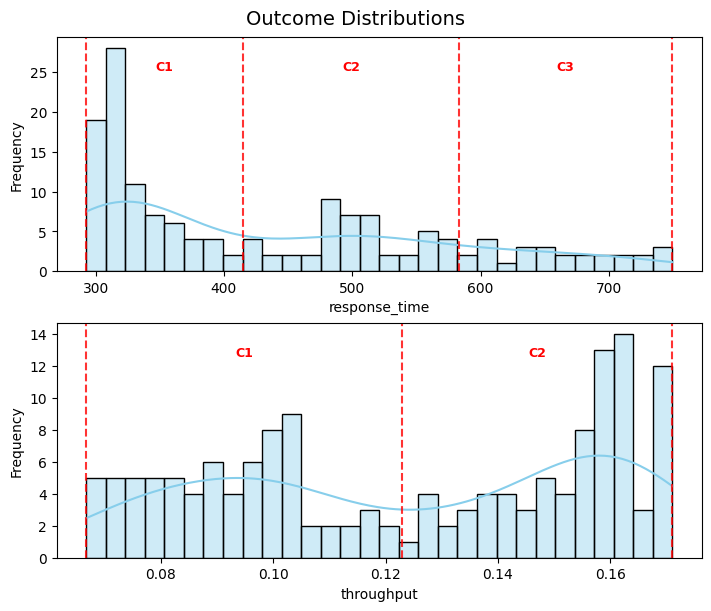

In [133]:
session.show_distributions(figsize=(7,3))
plt.show()

In [134]:
# Looking at each tradeoff region
# for tradeoff in session.get_tradeoffs():
#     indices = session.get_indices_for_tradeoff(tradeoff)
#     print(f"Plotting distribution for target tradeoff: {tradeoff.name}")
   
#     session.show_distributions(
#         tradeoff=tradeoff,
#         highlight_indices=indices
#     )
#     plt.show()

## 6. Quality Objective Space (2D Scatter)
We map the tradeoffs onto a 2D space to see their shape and density. Readability enhancements include bottom-aligned legends and bottom-to-top orientation for Y-axis bin labels.

In [135]:
tradeoff_labels = [t.name for t in tradeoffs]
tradeoff_labels

['C1-C1', 'C1-C2', 'C2-C1', 'C2-C2', 'C3-C1', 'C3-C2']

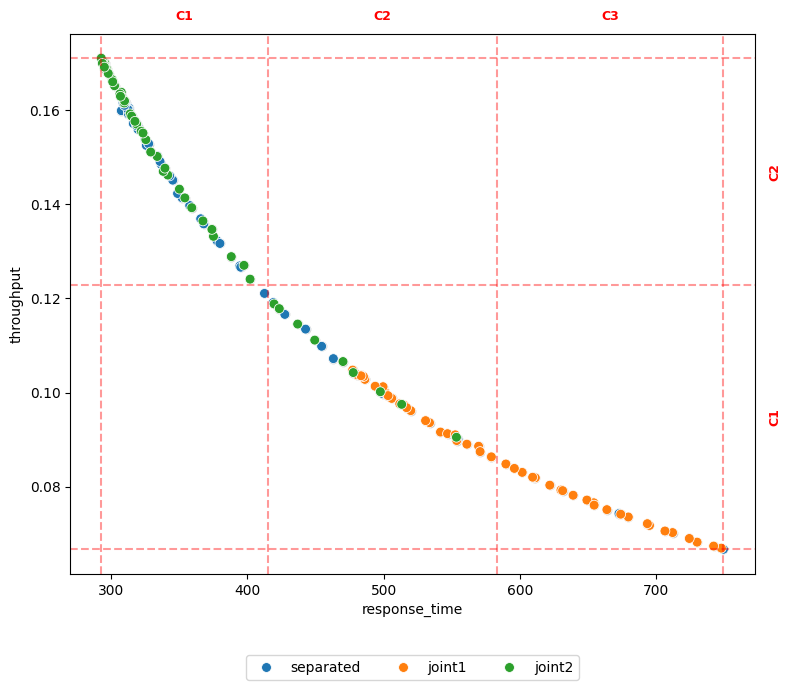

In [136]:
outcome_cols = list(session.outcomes_df.columns)
# Plot the policies for all combinations (pairs) of quality objectives
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    fig = session.show_quality_objective_space(
        x_col, y_col,
        highlight_policies=session.get_policies(), 
        # highlight_tradeoffs=[session.get_tradeoff(tradeoffs[1].name)],
        # show_overall=True,
        subset='all',
        cmap='tab10', 
        alpha=1.0,
        figsize=(8, 7),
        s=50,
        title=""
    )
    fig.savefig(f'paf-quality_objective_space_{x_col}_{y_col}.png', dpi=500)
    plt.show()


## 7. Contingency Analysis (Impact of Decisions)
This stage quantifies the relationship between choices and outcomes. We compute:
- **Heatmaps**: Visualizing the probability of landing in a specific tradeoff given a policy.
- **Deterministic Policies**: Identifying configurations that lead to a single outcome with >99% certainty.
- **Exclusive Tradeoffs**: Determining if certain high-performance results are only reachable via a specific design path.

Analyzing Decision: pipeline_structure


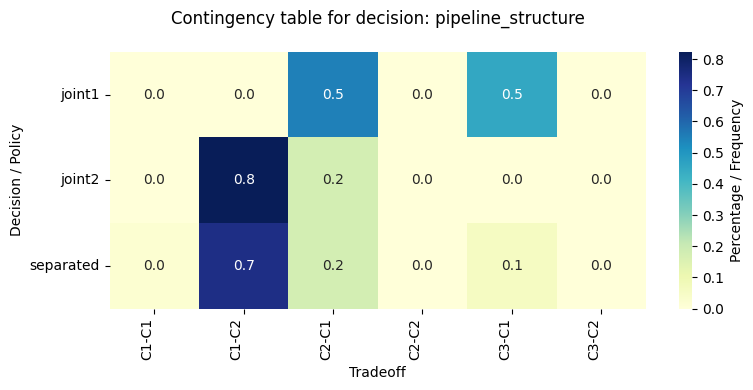

In [137]:
decisions = list(session.get_decisions().keys())
for decision_key in decisions:
    print(f"Analyzing Decision: {decision_key}")
    session.show_policy_contingency(
        decision_key, 
        type='heatmap', 
        subset='all',
        title=f"Contingency table for decision: {decision_key}",
        figsize=(8,4)
    )
    plt.show()

In [138]:
print("Deterministic policies (policies that consistently result in a single specific tradeoff)")
for decision_key in decisions:
    print("---"*10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_deterministic_policies(decision_key):
        print("* Policy:", policy, "--> Tradeoff:", tradeoff)


Deterministic policies (policies that consistently result in a single specific tradeoff)
------------------------------
Decision: pipeline_structure


In [139]:
session.get_policies()

{'separated': SystemConfiguration(name='separated', description='', pattern_policy_references=[PatternPolicyReference(component='pipesandfilters_pattern', decision='pipeline_structure', policy='separated')], source_file='separated/Core1_N50.csv', component_policies={}),
 'joint1': SystemConfiguration(name='joint1', description='', pattern_policy_references=[PatternPolicyReference(component='pipesandfilters_pattern', decision='pipeline_structure', policy='joint1')], source_file='joint/Core1_N50.csv', component_policies={}),
 'joint2': SystemConfiguration(name='joint2', description='', pattern_policy_references=[PatternPolicyReference(component='pipesandfilters_pattern', decision='pipeline_structure', policy='joint2')], source_file='joint/Core2_N50.csv', component_policies={})}

In [140]:
print("Exclusive tradeoffs (tradeoffs being addressed by a single decision (which might have several policies)")
for decision_key in decisions:
    print("---"*10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_exclusive_tradeoffs(decision_key):
        print("* Tradeoff:", tradeoff, "--> Decision:", decision_key, "[Policy:", policy, "]")

 

Exclusive tradeoffs (tradeoffs being addressed by a single decision (which might have several policies)
------------------------------
Decision: pipeline_structure
* Tradeoff: C1-C1 --> Decision: pipeline_structure [Policy: separated ]


## 8. Robustness Analysis (Quantifying Stability)
While contingency tells us *how often* we succeed, robustness tells us *how stable* that success is when parameters vary. We use two complementary metrics:
- **STARR (Success Rate)**: The percentage of points within a policy that meet the target requirements. Higher is better.
- **REGRET (Risk)**: The standardized distance from the closest successful point. It measures 'how bad' a failure is. Lower is better.

In [141]:
metric = 'starr' #'starr 'regret'

In [142]:
base_robustness_matrix = session.get_robustness_report(metric=metric, subset='test') 
base_robustness_matrix # Test


,C1-C1,C1-C2,C2-C1,C2-C2,C3-C1,C3-C2
policy,,,,,,
joint1,0.0,0.000000,0.571429,0.0,0.428571,0.0
joint2,0.0,0.842105,0.157895,0.0,0.000000,0.0
separated,0.0,0.818182,0.136364,0.0,0.045455,0.0


In [143]:
# session.get_policy_contingency_matrix(decision_key, subset='test')

Robustness Ranking for Tradeoff: C1-C1
  1. separated: 0.02% success
  2. joint1: 0.00% success
  3. joint2: 0.00% success
  Top Policy -> separated - Starr: 0.0196 - Regret: 0.8427
Robustness Ranking for Tradeoff: C1-C2
  1. joint2: 0.82% success
  2. separated: 0.75% success
  3. joint1: 0.00% success
  Top Policy -> joint2 - Starr: 0.8235 - Regret: 0.1145
Robustness Ranking for Tradeoff: C2-C1
  1. joint1: 0.55% success
  2. joint2: 0.18% success
  3. separated: 0.18% success
  Top Policy -> joint1 - Starr: 0.5490 - Regret: 0.2708
Robustness Ranking for Tradeoff: C2-C2
  1. joint1: 0.00% success
  2. joint2: 0.00% success
  3. separated: 0.00% success
  Top Policy -> joint1 - Starr: 0.0000 - Regret: 1.1478
Robustness Ranking for Tradeoff: C3-C1
  1. joint1: 0.45% success
  2. separated: 0.06% success
  3. joint2: 0.00% success
  Top Policy -> joint1 - Starr: 0.4510 - Regret: 0.2593
Robustness Ranking for Tradeoff: C3-C2
  1. joint1: 0.00% success
  2. joint2: 0.00% success
  3. sepa

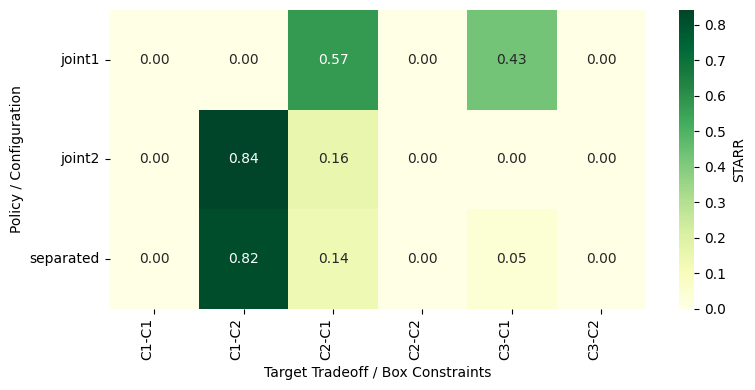

In [144]:
for tradeoff in session.get_tradeoffs():
    print(f"Robustness Ranking for Tradeoff: {tradeoff.name}")
    ranking = session.get_policy_robustness_ranking(tradeoff.name, metric='starr')
    for i, (pol, val) in enumerate(ranking[:3]):
        print(f"  {i+1}. {pol}: {val:.2f}% success")
    
    if ranking:
        top_pol = ranking[0][0]
        starr = session.compute_robustness(top_pol, tradeoff.name, metric='starr')
        regret = session.compute_robustness(top_pol, tradeoff.name, metric='regret')
        print(f"  Top Policy -> {top_pol} - Starr: {starr.get('value', 0.0):.4f} - Regret: {regret.get('value', 0.0):.4f}")

if metric == 'starr':
    print("Overall Robustness Heatmap (STARR):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='starr', figsize=(8,4))
    plt.show()

if metric == 'regret':
    print("Overall Robustness Heatmap (REGRET):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='regret', figsize=(8,4))
    plt.show()


## 9. Feature Importance (Sensitivity Analysis)
Not all parameters are equal. Using Random Forests, we rank features by their influence on outcomes. This identified which system parameters (e.g., service rates, user counts) truly 'drive' the architectural tradeoffs we defined in Step 3.

Scoring features for outcome: response_time (on subset: train)
Original features: ['c_A_T2', 'c_T2', 'c_T4', 'N_B', 'r_A_T2', 'c_A_T3', 'c_B_T2', 'c_A_T1', 'r_B_T4', 'r_A_T1', 'r_A_T3', 'c_T1', 'c_T3', 'r_B_T2', 'r_Z_B', 'r_B_T1', 'r_Z_A', 'c_B_T4', 'c_B_T1', 'N_A']
Features selected: ['c_T2', 'r_B_T4', 'r_Z_B', 'r_B_T1', 'r_Z_A', 'N_A']
Scoring features for outcome: throughput (on subset: train)
Original features: ['c_A_T2', 'c_T2', 'c_T4', 'N_B', 'r_A_T2', 'c_A_T3', 'c_B_T2', 'c_A_T1', 'r_B_T4', 'r_A_T1', 'r_A_T3', 'c_T1', 'c_T3', 'r_B_T2', 'r_Z_B', 'r_B_T1', 'r_Z_A', 'c_B_T4', 'c_B_T1', 'N_A']
Features selected: ['c_T2', 'r_B_T4', 'r_Z_B', 'r_B_T1', 'r_Z_A', 'N_A']


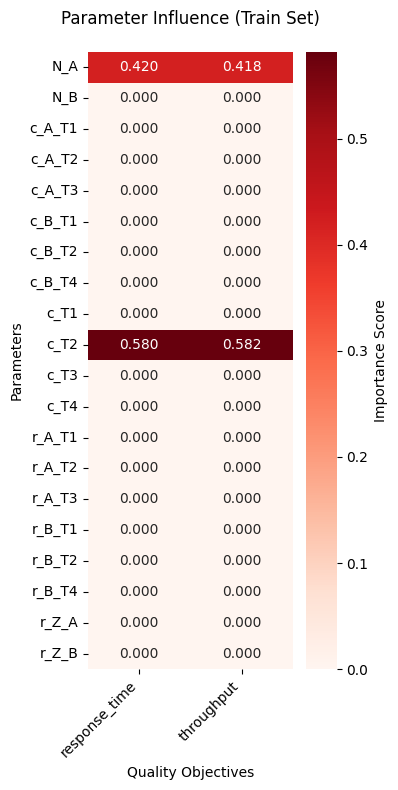

In [145]:
# Note: using smart correlation is more aggresive in the pruning of features, before scoring them
scores_df = session.compute_feature_scores(use_smart_correlation=True, subset='train')

session.show_feature_heatmap(scores_df, title="Parameter Influence (Train Set)", figsize=(4,8))
plt.show()

## 10. Scenario Discovery (PRIM)
We use the Patient Rule Induction Method (PRIM) to 'peel' the parameter space and find the 'Operating Envelopes' (Boxes) that reliably guarantee success. These rules define the boundaries of our robust architectural region for each target tradeoff.

In [146]:
# Key parameters identified in paper:
# kp = ['N_A', 'N_B']


In [147]:
weighted_features = session.get_weighted_feature_ranking(scores_df)
print(weighted_features)
key_parameters = session.select_top_k_parameters(scores_df, index_order=weighted_features, threshold=0.2, k=None)
print("Key parameters (for scenario discovery):", key_parameters)

# key_parameters = kp # To make it similar to the ECSA paper

['c_T2', 'N_A']
Key parameters (for scenario discovery): ['c_T2', 'N_A']


In [148]:
prim_boxes = []
for tradeoff in session.get_tradeoffs():
    print("---"*10)
    print(f"Discovering scenarios for: {tradeoff.name}")
    boxes = session.discover_scenarios(
        tradeoff.name, method='prim', 
        threshold=0.8, 
        standardize=True,
        parameters=key_parameters
    )
    if boxes:
        best_box = boxes[0]
        print(f"* Key Rules: {best_box.limits}")
        print(f"* Metrics: {best_box.metrics}")
        prim_boxes.append(best_box)
    else:
        print("--> No scenarios discovered.")

------------------------------
Discovering scenarios for: C1-C1
Running PRIM discovery for: C1-C1 ...
Instances satisfying property: False    90
True      1
Name: count, dtype: int64
Total instances: (91, 2)
Running PRIM ... rhodium
2 possible boxes
{'c_T2': {'min': 0.0, 'max': 2.0}, 'N_A': {'min': 0, 'max': 50}}
* Key Rules: {'c_T2': {'min': 0.0, 'max': 0.5}, 'N_A': {'min': 30.5, 'max': 38.5}}
* Metrics: {'density': 0.0, 'coverage': 0.0, 'population_prevalence': 0.01098901098901099, 'lift': -0.01098901098901099, 'samples_in_box': 3.0, 'targets_in_box': 0.0}
------------------------------
Discovering scenarios for: C1-C2
Running PRIM discovery for: C1-C2 ...
Instances satisfying property: True     46
False    45
Name: count, dtype: int64
Total instances: (91, 2)
Running PRIM ... rhodium
2 possible boxes
{'c_T2': {'min': 0.0, 'max': 2.0}, 'N_A': {'min': 0, 'max': 50}}
* Key Rules: {'N_A': {'min': 0.0, 'max': 47.5}}
* Metrics: {'density': 0.5666666666666667, 'coverage': 1.0, 'population_

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perf

In [149]:
boxes_to_keep = []
print("Summary of PRIM boxes:")
for idx, box in enumerate(prim_boxes):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): lift={lift:.2f} \n\t{box.limits}")
        # print(box.actual_limits)
        boxes_to_keep.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}) {solutions}")
prim_boxes = boxes_to_keep


Summary of PRIM boxes:
 Skipping empty box. For tradeoff C1-C1 (C1,C1) 0.0
 2. For tradeoff C1-C2 (C1,C2): lift=0.06 
	{'N_A': {'min': 0.0, 'max': 47.5}}
 3. For tradeoff C2-C1 (C2,C1): lift=0.62 
	{'c_T2': {'min': 0.5, 'max': 1.5}, 'N_A': {'min': 0.0, 'max': 27.0}}
 4. For tradeoff C3-C1 (C3,C1): lift=0.64 
	{'c_T2': {'min': 0.5, 'max': 1.5}, 'N_A': {'min': 20.5, 'max': 50.0}}


## 11. Global Discovery (CART)
Using decision trees, we partition the entire design space into regions, providing a global map of the most likely outcomes for any input combination.

In [150]:
boxes_to_keep = []
cart_boxes = session.discover_scenarios(
                method='cart', 
                standardize=True, 
                parameters=key_parameters
            )
for idx, box in enumerate(cart_boxes):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): lift={lift:.2f} \n\t{box.limits}")
        # print(box.actual_limits)
        boxes_to_keep.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}) {solutions}")
cart_boxes = boxes_to_keep

Running CART global discovery for all tradeoff combinations ...
 Skipping empty box. For tradeoff C2-C1 (C2,C1) 0.0
 2. For tradeoff C1-C2 (C1,C2): lift=0.16 
	{'c_T2': {'min': 1.5000865114870063, 'max': inf}, 'N_A': {'min': 27.507486788817772, 'max': 43.49720229035502}}
 Skipping empty box. For tradeoff C3-C1 (C3,C1) 0.0
 Skipping empty box. For tradeoff C1-C1 (C1,C1) 0.0


## 12. Potential Robustness Improvements (What-If Analysis)
Finally, we simulate the impact of applying discovered scenario constraints. We compare **Baseline Robustness** vs. **Improved Robustness** to quantify the value of the discovered 'Operating Envelopes' for each policy.

In [151]:
combined_df = session.get_robustness_results(prim_boxes, cart_boxes, baseline=base_robustness_matrix)
combined_df.to_csv('results-paf.csv', index=False, decimal=',')
combined_df

,method,policy,target,C1-C1,C1-C2,C2-C1,C2-C2,C3-C1,C3-C2
0,test set,joint1,,0.0,0.000000,0.571429,0.0,0.428571,0.0
1,test set,joint2,,0.0,0.842105,0.157895,0.0,0.000000,0.0
2,test set,separated,,0.0,0.818182,0.136364,0.0,0.045455,0.0
3,prim,joint1,C1-C2,0.0,0.000000,0.600000,0.0,0.400000,0.0
4,prim,joint1,C2-C1,0.0,0.000000,0.923077,0.0,0.076923,0.0
5,prim,joint1,C3-C1,0.0,0.000000,0.181818,0.0,0.818182,0.0
6,prim,joint2,C1-C2,0.0,0.888889,0.111111,0.0,0.000000,0.0
7,prim,joint2,C2-C1,0.0,0.000000,0.000000,0.0,0.000000,0.0
8,prim,joint2,C3-C1,0.0,0.000000,0.000000,0.0,0.000000,0.0
9,prim,separated,C1-C2,0.0,0.818182,0.136364,0.0,0.045455,0.0


In [152]:
prim_box_list = session.align_boxes_to_tradeoffs(prim_boxes) # PRIM

prim_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(prim_box_list, metric=metric, subset='test')
prim_robustness_improvement_matrix

,C1-C1,C1-C2,C2-C1,C2-C2,C3-C1,C3-C2
joint1,None,0.000000,0.923077,None,0.818182,None
joint2,None,0.888889,0.000000,None,0.000000,None
separated,None,0.818182,0.000000,None,0.000000,None


In [153]:
session.get_tradeoff_coverage_matrix(prim_boxes, subset='test')

,C1-C1,C1-C2,C2-C1,C2-C2,C3-C1,C3-C2
C1-C2,0.0,1.0,0.944444,0.0,0.9,0.0
C2-C1,0.0,0.0,0.666667,0.0,0.1,0.0
C3-C1,0.0,0.0,0.111111,0.0,0.9,0.0


In [154]:
# fig = session.show_policy_robustness_improvement_heatmap(
#     boxes=prim_box_list, 
#     matrix=prim_robustness_improvement_matrix,
#     metric=metric,
#     figsize=(8, 4),
#     title="What-If Analysis: Policy Success under Box Constraints (PRIM)"
# )


In [155]:
cart_box_list = session.align_boxes_to_tradeoffs(cart_boxes) # CART

cart_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(cart_box_list, metric=metric, subset='test')
cart_robustness_improvement_matrix

,C1-C1,C1-C2,C2-C1,C2-C2,C3-C1,C3-C2
joint1,None,0.000000,None,None,None,None
joint2,None,0.666667,None,None,None,None
separated,None,0.000000,None,None,None,None


In [156]:
session.get_tradeoff_coverage_matrix(cart_boxes, subset='test')

,C1-C1,C1-C2,C2-C1,C2-C2,C3-C1,C3-C2
C1-C2,0.0,0.117647,0.111111,0.0,0.0,0.0


In [157]:
# fig = session.show_policy_robustness_improvement_heatmap(
#     boxes=cart_box_list, 
#     matrix=cart_robustness_improvement_matrix,
#     metric=metric,
#     figsize=(8, 4),
#     title="What-If Analysis: Policy Success under Box Constraints (CART)"
# )

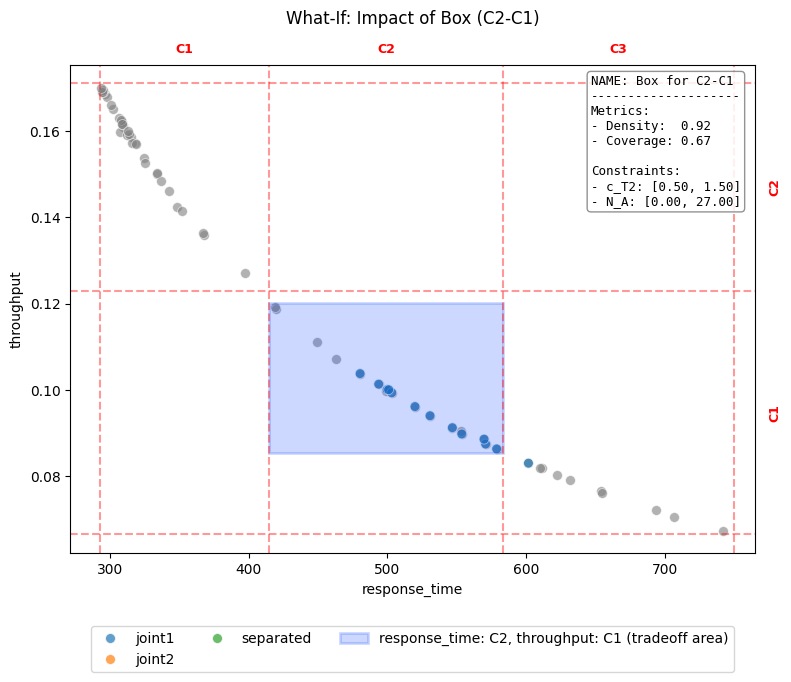

In [158]:
# Visuallization of example box
idx = 2
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    session.show_box_impact_objective_space(
        box=prim_box_list[idx],
        x_metric=x_col, 
        y_metric=y_col,
        tradeoff=session.get_tradeoff(tradeoffs[idx].name),
        show_box_summary=True,
        subset='test',
        cmap='tab10', 
        alpha=0.7,
        figsize=(8, 7),
        s=50
    )
    plt.show()

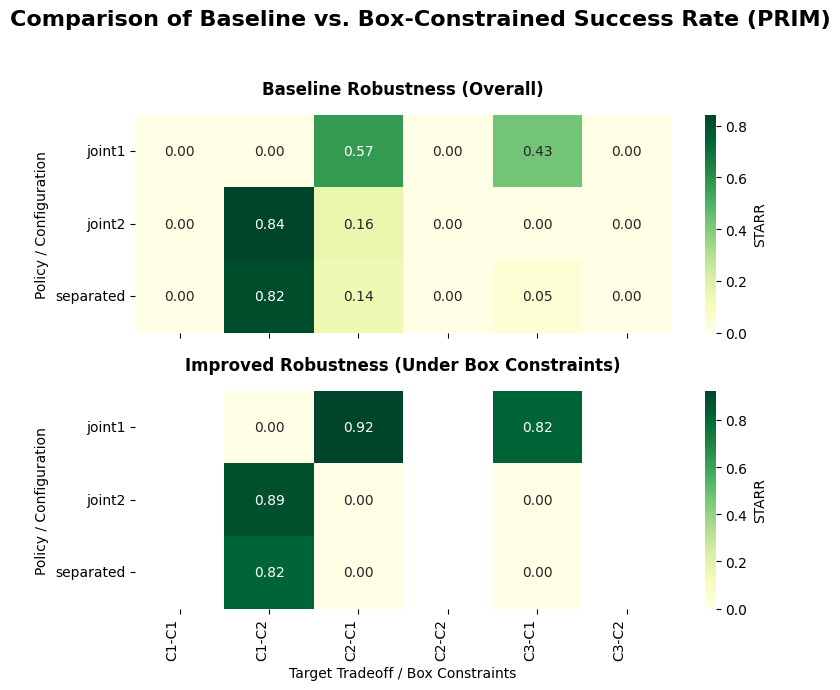

In [159]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=prim_robustness_improvement_matrix,
    boxes=prim_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (PRIM)"
)

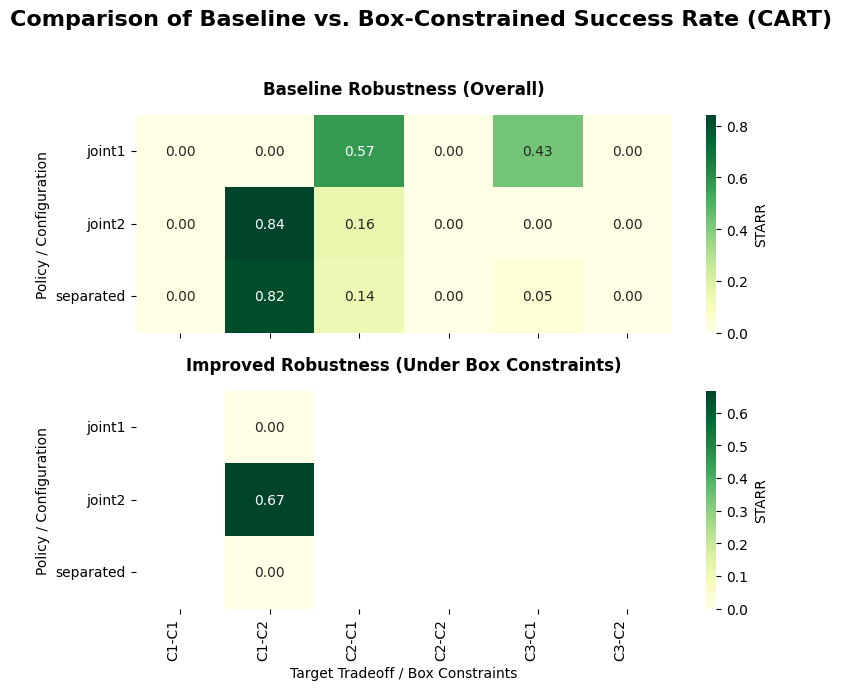

In [160]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=cart_robustness_improvement_matrix,
    boxes=cart_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (CART)"
)

---

In [161]:
scores = session.get_algorithm_performance_scores(prim_boxes, return_std=True)
pd.DataFrame(scores.items(), columns=['metric', 'value'])


,metric,value
0,precision,0.375132
1,recall,0.408305
2,f1,0.373069
3,lift,0.208466
4,complexity,1.666667
5,success_rate,0.500000
6,precision_std,0.390367
7,recall_std,0.428512
8,f1_std,0.374979
9,lift_std,0.285988


In [162]:
scores = session.get_algorithm_performance_scores(cart_boxes, return_std=True)
pd.DataFrame(scores.items(), columns=['metric', 'value'])


,metric,value
0,precision,0.145833
1,recall,0.029167
2,f1,0.048611
3,lift,-0.020833
4,complexity,2.000000
5,success_rate,0.166667
6,precision_std,0.326093
7,recall_std,0.065219
8,f1_std,0.108698
9,lift_std,0.200292


In [163]:
# agg_stats = session.get_aggregate_robustness_stats(prim_boxes, metric='starr')
# agg_stats

In [164]:
# agg_stats = session.get_aggregate_robustness_stats(cart_boxes, metric='starr')
# agg_stats